In [44]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Ensure Python can find your emulator library
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
sys.path.insert(0,str(REPO_ROOT / '..' / 'qick_lib/'))
print(sys.path)
source_dir = REPO_ROOT / 'software'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import qick_emu
importlib.reload(qick_emu)
from qick_emu import QickEmu
from qick.asm_v2 import AveragerProgramV2


['/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/../qick_lib', '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/../qick_lib', '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/../qick_lib', '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/../qick_lib', '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/software', '/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/../qick_lib', '/usr/lib64/python39.zip', '/usr/lib64/python3.9', '/usr/lib64/python3.9/lib-dynload', '', '/home/dmartin2/venv/lib64/python3.9/site-packages', '/home/dmartin2/hrl-labs-clinic/qick_fork_mmdiego_qickemu/qick_lib', '/home/dmartin2/venv/lib/python3.9/site-packages']


## Overview: real-time feedback in QICK

The following demo shows an experiment that demonstrates the QICK tprocv2 capabilities, namely the arithmetic logic capabilities, branching logic, real-time parametric pulse generation, and LFSR based random number generation. The configuration is as follows: channel 0 of the RFSoC is plugged into readout channel 4. A random number is generated with the top 16 bits shifted into a register. The random number is mapped to the amplitude wave parameter of that pulse envelope. The pulse is sent into channel 4, where it is demodulated and averaged, returning an amplitude. The program checks the measured amplitude. If the amplitude is lower than a given amount, it fires a pulse from the channel 2 DAC. TRM manual describing instructions found here: https://github.com/meeg/qick_demos_sho/blob/main/tprocv2/qick_processor_TRM.pdf

In [45]:
# emulator init
# CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_config_216.json'
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_emu_config.json'
soc      = QickEmu(str(CFG_PATH))
soccfg   = soc.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / 'hmc_clinic_feedback_emu'
# ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / 'qick_emu_data'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

# Default Path is the artifacts root.
OUT = ARTIFACTS_ROOT

## QICKEmu Auxiliary Functions
def QICKEmu_plot_dac(soc, OUT):
    # DAC waveform
    t_dac, dac = soc.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

def QICKEmu_plot_all_dacs(soc_emu, OUT):
    # DAC waveform
    t_dac_ch0, dac_ch0 = soc_emu.load_dac(emu_dir=OUT, gen_ch=0, absolute_time=True)
    t_dac_ch1, dac_ch1 = soc_emu.load_dac(emu_dir=OUT, gen_ch=1, absolute_time=True)    

    plt.figure(figsize=(10, 3))

    plt.plot(t_dac_ch0, dac_ch0, linewidth=0.8)
    plt.plot(t_dac_ch1, dac_ch1, linewidth=0.8)

    plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()


QICK library version mismatch: 0.2.366 remote (the board), 0.2.85 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator
ARTIFACTS_ROOT: /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/artifacts/hmc_clinic_feedback_emu
QICK running on QICKEmu, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	3 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is QICKEmu DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is QICKEmu DAC port 1
	2:	axis_sg_mux8_v1 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex sa

In [46]:
from qick.tprocv2_assembler import Assembler

def pstr2asm_inst(self, pstr_lst):
    pstr = '\n'.join(pstr_lst) + '\n'
    asm_dict, labels = Assembler.str_asm2list(pstr)
    for label, addr in labels.items():
        if addr != label:   # skip pre-defined assembler symbols (e.g. 's15': 's15')
            self.label(label)
    for instr in asm_dict:
        self.asm_inst(instr)

# -----------------------------------------------------------------------------
# FIXED MACROS: Inject raw dictionaries to bypass isolated label parsing errors
# -----------------------------------------------------------------------------
def NOP(self):
    self.label('END_SETUP')

def JUMP(self, label):
    self.asm_inst({'CMD': 'JUMP', 'LABEL': label})

def CALL(self, label, cond=None):
    inst = {'CMD': 'CALL', 'LABEL': label}
    if cond is not None:
        inst['IF'] = cond
    self.asm_inst(inst)

def exitREP(self):
    self.label('exitREP')

def SETUP_PULSE(self, cfg): 
    pstr_lst = [
        f'REG_WR w_gain imm #{str(cfg["gain"])}',
        f'REG_WR w_phase imm #{self.deg2reg(cfg["phase"], gen_ch=cfg["gen_ch"])}',
        f'REG_WR w_env imm #0',
        f'REG_WR w_length imm #{self.us2cycles(cfg["pulse_len"], gen_ch=cfg["gen_ch"])}',
        f'REG_WR w_conf imm #9',
        f'REG_WR w_freq imm #{self.freq2reg(cfg["freq"], gen_ch=cfg["gen_ch"])}',
        'WMEM_WR [&0]'
    ]
    pstr2asm_inst(self, pstr_lst)

def SETUP_FEED(self):
    pstr_lst = [
        f'REG_WR w_gain imm #{str(15000)}',
        f'REG_WR w_phase imm #{self.deg2reg(90, gen_ch=2)}',
        f'REG_WR w_env imm #0',
        f'REG_WR w_length imm #{self.us2cycles(0.1, gen_ch=2)}',
        f'REG_WR w_conf imm #9',
        f'REG_WR w_freq imm #{self.freq2reg(1000, gen_ch=2)}',
        'WMEM_WR [&1]'
    ]
    pstr2asm_inst(self, pstr_lst)

def LFSR_sub(self):
    pstr_lst = [
        'LFSR:',
        'REG_WR r26 op -op(s1)',
        'REG_WR r28 op -op(MSH r26)',
        'RET',
    ]
    pstr2asm_inst(self, pstr_lst)

def set_wport_on(self):
    pstr_lst = ['WPON:', 'REG_WR w_gain imm #32766', 'WMEM_WR [&0]', 'RET']
    pstr2asm_inst(self, pstr_lst)

def set_wport_off(self):
    pstr_lst = ['WPOFF:', 'REG_WR w_gain imm #0', 'WMEM_WR [&0]', 'RET']
    pstr2asm_inst(self, pstr_lst)

def cond_out(self):
    # External CALL targets (LFSR, WPON, WPOFF) are not in this string's label_dict,
    # so they must be injected via self.asm_inst to be resolved at link time.
    pstr2asm_inst(self, ['CONDOUT:'])
    CALL(self, 'LFSR')
    pstr2asm_inst(self, ['REG_WR r28 op -op(r28 SR #5)', 'TEST -op(r28 AND #8) -uf'])
    CALL(self, 'WPON', cond='NZ')
    CALL(self, 'WPOFF', cond='Z')
    pstr2asm_inst(self, ['TEST -op(r28) -uf', 'RET'])

def rand_amp(self):
    pstr2asm_inst(self, ['RANDAMP:'])
    CALL(self, 'LFSR')
    pstr2asm_inst(self, ['REG_WR w_gain op -op(ABS r28)', 'WMEM_WR [&0]', 'RET'])

def read_and_jump(self):
    pstr2asm_inst(self, ['THRES:', 'REG_WR r31 op -op(r1)', 'TEST -op(r31 - #500) -uf'])
    CALL(self, 'playPULSE2', cond='Z')
    pstr2asm_inst(self, ['RET'])

def playPULSE1(self, port): 
    pstr2asm_inst(self, ['playPULSE1:', f'WPORT_WR p{port} wmem [&0]', 'RET'])

def playPULSE2(self, port): 
    pstr2asm_inst(self, ['playPULSE2:', f'WPORT_WR p{port} wmem [&1]', 'RET'])

In [47]:
'''
Feedback
'''

class feedback_test(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        shots = cfg['shots']
        gain = cfg['gain']
        feed_ch = cfg['feed_ch']

        self.declare_gen(ch=gen_ch)
        self.declare_gen(ch=feed_ch)

        self.declare_readout(ch=ro_ch, length=cfg['ro_len'], freq=cfg['freq'], gen_ch=gen_ch)

        # self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
        # self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        # self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

        self.add_pulse(ch=gen_ch, name="mypulse", freq=cfg['freq'], phase=0,
                       length=cfg['pulse_len'], style="const", mode="oneshot",
                       stdysel="zero", gain=gain)
        
        self.add_pulse(ch=feed_ch, name="feedpulse", freq=1000, phase=0,
                       length=0.5, style="const", mode="oneshot",
                       stdysel="zero", gain=gain)

        cfg['gain'] = 32766
        
        SETUP_PULSE(self, cfg)
        
        # FIXED: Tell it to jump to the renamed label
        JUMP(self, "END_SETUP")
        
        playPULSE1(self, gen_ch)
        playPULSE2(self, feed_ch)

        fb_labels = [LFSR_sub, set_wport_on, set_wport_off, cond_out, read_and_jump, rand_amp]
        for label in fb_labels:
            label(self)
        
        NOP(self) # This now drops the 'END_SETUP:' label
        self.add_loop("ShotLoop", shots)

        # Initialize the random number generator with a seed
        self.write_reg(dst='s_rand', src=987654321)

    def _body(self, cfg):

        # Use the call command and labels used in routines to call functions. First setup random amplitude or 
        # conditional out experiment
        
        #CALL(self, 'CONDOUT') # uncomment for conditional out experiment
        CALL(self, 'RANDAMP') 

        CALL(self, 'playPULSE1')

        #call readout
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)

        # wait, then delay a bit extra
        self.wait_auto(cfg['feed_delay'])
        self.delay_auto(cfg['feed_delay'] + cfg['extra_delay'])

        # a second trigger ensures that the readout is fully filled
        self.trigger(ros=[cfg['ro_ch']], t=cfg['trig_time'],  ddr4=True)

        # add a conditional statement thresholded on the Q quadrature of the non-decimated readout buffer
        self.read_and_jump(cfg['ro_ch'], component='Q', threshold=500, test="<", label='NOPULSE')

        # if it is less than threshold, play this pulse
        self.pulse(ch=cfg['feed_ch'], name="feedpulse", t=0)

        # if not, it will jump to this label, skipping the second pulse
        self.label("NOPULSE")

        # add a small delay at end of experiment 
        self.delay_auto(t=cfg['meas_delay'] + cfg['pulse_len'])


# =============================================================================
# 3. Emulator Execution & Generation
# =============================================================================

config = {'gen_ch': 1,
          'feed_ch':0,
          'ro_ch': 1,
          'freq': 100,
          'phase':0,
          'trig_time': 0.01,
          'ro_len': 1,
        #   'shots': 10000,
          'shots': 10,
          'meas_delay': 2,
          'pulse_len':1,
          'gain':1,
          "feed_delay": 0.2,
          'extra_delay': 0.0,
          }


prog = feedback_test(soccfg, reps=1, final_delay=.5, cfg=config)


Artifacts -> /home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/artifacts/hmc_clinic_feedback_emu/hmc_feedback
[sim] Running simulation with EMU_DIR=/home/dmartin2/hrl-labs-clinic/qick_hrl_clinic_b_features/emulator/artifacts/hmc_clinic_feedback_emu/hmc_feedback ...


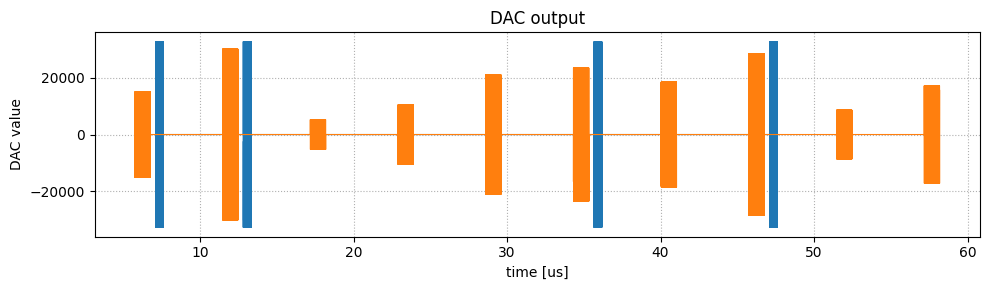

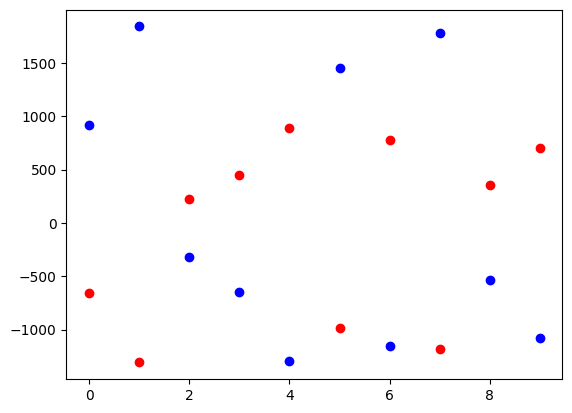

In [48]:
# emulator artifacts
OUT = ARTIFACTS_ROOT / 'hmc_feedback'
OUT.mkdir(parents=True, exist_ok=True)

soc = soc.prepare_emu(memdir=OUT, test_run_ns=75_000, trace=False, verbose=False)
print(f'Artifacts -> {OUT}')


soc.tproc.set_lfsr_cfg(2) # set the LFSR to update on a read, more can be found here: https://docs.qick.dev/latest/_autosummary/qick.drivers.tproc.html#qick.drivers.tproc.Axis_QICK_Proc.set_lfsr_cfg

d = prog.acquire(soc=soc, rounds=1)

# Plot DAC waveform
QICKEmu_plot_all_dacs(soc, OUT)

i_data = d[0][0].T[0]
q_data = d[0][0].T[1]
mag = np.sqrt(i_data**2+q_data**2)

plt.plot(q_data, 'ob')
plt.plot(i_data, 'or')

In [50]:
'''
Print program out to show what is going on
'''
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 1, 'LINE': 1, 'LIT': '#32766', 'CMD': 'REG_WR', 'DST': 'w3', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 2, 'LINE': 2, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w1', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 3, 'LINE': 3, 'LIT': '#0', 'CMD': 'REG_WR', 'DST': 'w2', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 4, 'LINE': 4, 'LIT': '#599', 'CMD': 'REG_WR', 'DST': 'w4', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 5, 'LINE': 5, 'LIT': '#9', 'CMD': 'REG_WR', 'DST': 'w5', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 6, 'LINE': 6, 'LIT': '#44810940', 'CMD': 'REG_WR', 'DST': 'w0', 'SRC': 'imm'}, addr_inc=1)
	AsmInst(inst={'P_ADDR': 7, 'LINE': 7, 'CMD': 'WMEM_WR', 'DST': '[&0]'}, addr_inc=1)
	AsmInst(inst={'CMD': 'JUMP', 'LABEL': 'END_SETUP'}, addr_inc=1)
	Label(label='playPULSE1')
	AsmInst(inst={'P_ADDR': 0, 'CMD': 'NOP'}, addr_inc=1)
	Asm